# Exchange Rate Forecasting — ARIMA, ARIMAX and VAR

This notebook uses the processed monthly dataset to fit the final time-series models used for EUR/USD forecasting. The chronological 80:20 split from the original project is preserved.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_DIR = Path("../data")
master_monthly = pd.read_csv(DATA_DIR / "processed_monthly_exchange_data.csv", parse_dates=["Date"])

train_size = int(len(master_monthly) * 0.8)
train = master_monthly["EURUSD"][:train_size]
test = master_monthly["EURUSD"][train_size:]

print("Dataset shape:", master_monthly.shape)
print("Train size:", len(train))
print("Test size:", len(test))

Dataset shape: (192, 11)
Train size: 153
Test size: 39


## 1. ARIMA model selection

The original project compared five candidate ARIMA specifications. The final implementation uses ARIMA(0,1,1), following the original project's parsimony and diagnostic-based selection even though ARIMA(1,1,0) has a slightly lower AIC/BIC.

In [2]:
orders = [(0,1,1), (1,1,0), (1,1,1), (2,1,1), (1,1,2)]
results = []

for order in orders:
    try:
        fit = ARIMA(train, order=order).fit()
        results.append({
            "Model": f"ARIMA{order}",
            "AIC": fit.aic,
            "BIC": fit.bic
        })
    except Exception as e:
        print(f"Skipping {order}: {e}")

arima_selection = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print(arima_selection)

            Model         AIC         BIC
0  ARIMA(1, 1, 0) -708.894711 -702.846950
1  ARIMA(0, 1, 1) -708.871460 -702.823699
2  ARIMA(1, 1, 1) -707.061423 -697.989781
3  ARIMA(2, 1, 1) -705.067360 -692.971838
4  ARIMA(1, 1, 2) -705.030561 -692.935039


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 2. Final ARIMA(0,1,1)

In [3]:
arima_model = ARIMA(master_monthly["EURUSD"], order=(0,1,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

forecast_12 = arima_fit.forecast(steps=12)
print("\n12-Month EURUSD Forecast:")
print(forecast_12)

                               SARIMAX Results                                
Dep. Variable:                 EURUSD   No. Observations:                  192
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 457.852
Date:                Thu, 24 Sep 2026   AIC                           -911.704
Time:                        19:36:05   BIC                           -905.199
Sample:                             0   HQIC                          -909.069
                                - 192                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2953      0.077      3.824      0.000       0.144       0.447
sigma2         0.0005   3.94e-05     12.293      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [4]:
train_arima = ARIMA(train, order=(0,1,1)).fit()
test_forecast = train_arima.forecast(steps=len(test))

rmse_arima = np.sqrt(mean_squared_error(test, test_forecast))
mae_arima = mean_absolute_error(test, test_forecast)
mape_arima = np.mean(np.abs((test - test_forecast) / test)) * 100

print("ARIMA (0,1,1) Model Performance")
print("RMSE:", rmse_arima)
print("MAE:", mae_arima)
print("MAPE:", mape_arima)

ARIMA (0,1,1) Model Performance
RMSE: 0.11494419719693529
MAE: 0.10686036184792377
MAPE: 9.651616453003149


## 3. ARIMAX with macroeconomic variables

In [5]:
exog_vars = master_monthly[
    ["DXY", "Brent_Oil", "Fed_Funds", "CPI", "Trade_Balance"]
]
exog_train = exog_vars[:train_size]
exog_test = exog_vars[train_size:]

arimax_model = ARIMA(
    train,
    exog=exog_train,
    order=(0,1,1)
)
arimax_fit = arimax_model.fit()

print(arimax_fit.summary())

arimax_forecast = arimax_fit.forecast(
    steps=len(test),
    exog=exog_test
)

rmse_arimax = np.sqrt(mean_squared_error(test, arimax_forecast))
mae_arimax = mean_absolute_error(test, arimax_forecast)
mape_arimax = np.mean(np.abs((test - arimax_forecast) / test)) * 100

print("\nARIMAX (0,1,1) Model Performance")
print("RMSE:", rmse_arimax)
print("MAE:", mae_arimax)
print("MAPE:", mape_arimax)

                               SARIMAX Results                                
Dep. Variable:                 EURUSD   No. Observations:                  153
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 518.555
Date:                Thu, 24 Sep 2026   AIC                          -1023.111
Time:                        19:36:05   BIC                          -1001.944
Sample:                             0   HQIC                         -1014.512
                                - 153                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
DXY              -0.0160      0.000    -41.843      0.000      -0.017      -0.015
Brent_Oil        -0.0002      0.000     -1.973      0.048      -0.000   -1.54e-06
Fed_Funds         0.0003      0.004     


ARIMAX (0,1,1) Model Performance
RMSE: 0.0724768888989872
MAE: 0.06823074992653075
MAPE: 6.179816565538458


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


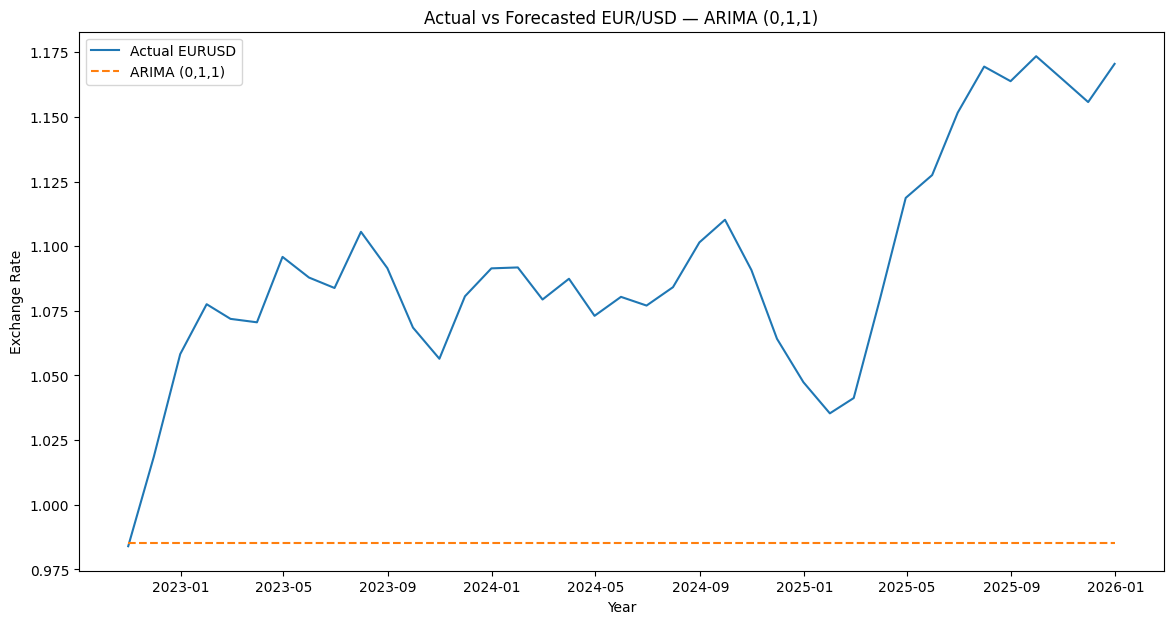

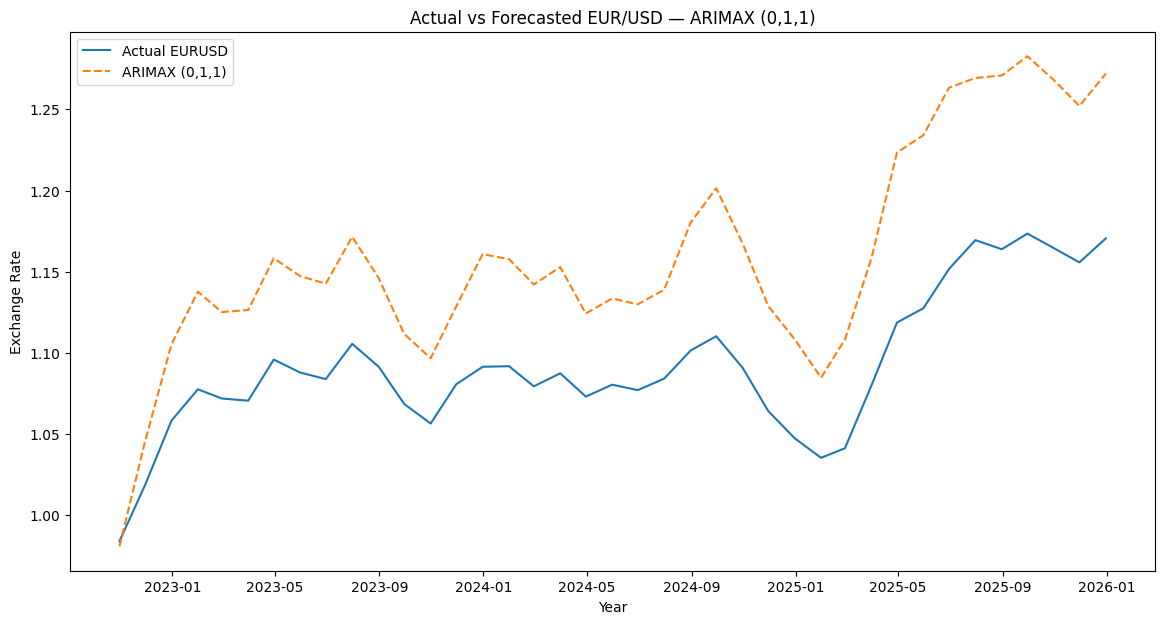

In [6]:
dates_test = master_monthly["Date"][train_size:]

plt.figure(figsize=(14, 7))
plt.plot(dates_test, test.reset_index(drop=True), label="Actual EURUSD")
plt.plot(dates_test, test_forecast.reset_index(drop=True), label="ARIMA (0,1,1)", linestyle="--")
plt.title("Actual vs Forecasted EUR/USD — ARIMA (0,1,1)")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(dates_test, test.reset_index(drop=True), label="Actual EURUSD")
plt.plot(dates_test, arimax_forecast.reset_index(drop=True), label="ARIMAX (0,1,1)", linestyle="--")
plt.title("Actual vs Forecasted EUR/USD — ARIMAX (0,1,1)")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## 4. VAR model

The VAR model is estimated on first differences of EUR/USD and selected macroeconomic variables. The original implementation selects lag 1 using AIC/BIC and evaluates EUR/USD forecasts on the differenced test series.

In [7]:
var_data = master_monthly[["EURUSD", "DXY", "Brent_Oil", "Fed_Funds", "CPI"]]
var_data_diff = var_data.diff().dropna()

train_var = var_data_diff[:train_size].copy()
test_var = var_data_diff[train_size:].copy()

var_model_base = VAR(train_var)
lag_order = var_model_base.select_order(maxlags=12)
print(lag_order.summary())

var_model = var_model_base.fit(1)

train_var.index = pd.RangeIndex(start=0, stop=len(train_var), step=1)
test_var.index = pd.RangeIndex(start=0, stop=len(test_var), step=1)

forecast_var = var_model.forecast(train_var.values[-1:], steps=len(test_var))
forecast_var_df = pd.DataFrame(forecast_var, columns=train_var.columns)

forecast_eurusd_var = forecast_var_df["EURUSD"]
actual_eurusd_var = test_var["EURUSD"]

rmse_var = np.sqrt(mean_squared_error(actual_eurusd_var, forecast_eurusd_var))
mae_var = mean_absolute_error(actual_eurusd_var, forecast_eurusd_var)
mape_var = np.mean(
    np.abs((actual_eurusd_var - forecast_eurusd_var) / actual_eurusd_var)
) * 100

print("VAR Model Performance")
print("RMSE:", rmse_var)
print("MAE:", mae_var)
print("MAPE:", mape_var)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -10.52      -10.42   2.689e-05      -10.48
1      -11.73*     -11.10*  8.066e-06*     -11.47*
2       -11.55      -10.40   9.607e-06      -11.09
3       -11.54      -9.865   9.798e-06      -10.86
4       -11.38      -9.188   1.150e-05      -10.49
5       -11.32      -8.606   1.233e-05      -10.22
6       -11.20      -7.962   1.413e-05      -9.886
7       -10.99      -7.228   1.783e-05      -9.463
8       -10.84      -6.550   2.143e-05      -9.095
9       -10.69      -5.878   2.582e-05      -8.733
10      -10.68      -5.352   2.717e-05      -8.518
11      -10.63      -4.774   3.048e-05      -8.250
12      -10.50      -4.123   3.731e-05      -7.909
--------------------------------------------------
VAR Model Performance
RMSE: 0.02119998551336518
MAE: 0.01670398882638184
MAPE: 136.07237208536466


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
